# MSA 2026 Phase 2 - Part 1

In [232]:
import sklearn
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
%matplotlib inline




## 1. Find all variables and understand them

In [233]:
df= pd.read_csv("store_sales.csv",encoding="latin-1")
df.head(10)



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,7/16/2017,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,9/25/2015,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,84057,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,9/17/2015,9/21/2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,12/8/2016,12/10/2016,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,...,75080,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


## 2. Clean data

In [234]:
df.info()
df.describe()
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [235]:
df["Order Date"].dtype

dtype('<M8[ns]')

In [236]:
df["Ship Date"].dtype

dtype('<M8[ns]')

translate the date object to number

In [237]:
df["Order Year"]    = df["Order Date"].dt.year       
df["Order Month"]   = df["Order Date"].dt.month      
df["Order Week"]    = df["Order Date"].dt.isocalendar().week  
df["Order Weekday"] = df["Order Date"].dt.dayofweek 
df[["Order Date", "Order Year", "Order Month", "Order Week", "Order Weekday"]].head(11) 


,Order Date,Order Year,Order Month,Order Week,Order Weekday
0,2016-11-08,2016,11,45,1
1,2016-11-08,2016,11,45,1
2,2015-10-11,2015,10,41,6
3,2014-06-09,2014,6,24,0
4,2014-06-09,2014,6,24,0
5,2017-07-16,2017,7,28,6
6,2015-09-25,2015,9,39,4
7,2015-09-17,2015,9,38,3
8,2015-09-17,2015,9,38,3
9,2016-12-08,2016,12,49,3


In [238]:
drop_cols = [
    "Row ID", "Order ID", "Customer ID", "Customer Name",
    "Product ID", "Product Name", "Country", "Category",
    "City", "State", "Postal Code"
]

df_clean = df.drop(columns=drop_cols)
print("Shape after dropping columns:", df_clean.shape)
df_clean.head()


Shape after dropping columns: (2121, 14)


,Order Date,Ship Date,Ship Mode,Segment,Region,Sub-Category,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Week,Order Weekday
0,2016-11-08,2016-11-11,Second Class,Consumer,South,Bookcases,261.9600,2,0.00,41.9136,2016,11,45,1
1,2016-11-08,2016-11-11,Second Class,Consumer,South,Chairs,731.9400,3,0.00,219.5820,2016,11,45,1
2,2015-10-11,2015-10-18,Standard Class,Consumer,South,Tables,957.5775,5,0.45,-383.0310,2015,10,41,6
3,2014-06-09,2014-06-14,Standard Class,Consumer,West,Furnishings,48.8600,7,0.00,14.1694,2014,6,24,0
4,2014-06-09,2014-06-14,Standard Class,Consumer,West,Tables,1706.1840,9,0.20,85.3092,2014,6,24,0


In [239]:
cat_cols = ["Ship Mode", "Segment", "Region", "Sub-Category"]
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, dtype=int)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (2121, 25)


,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Week,Order Weekday,...,Segment_Corporate,Segment_Home Office,Region_Central,Region_East,Region_South,Region_West,Sub-Category_Bookcases,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
0,2016-11-08,2016-11-11,261.9600,2,0.00,41.9136,2016,11,45,1,...,0,0,0,0,1,0,1,0,0,0
1,2016-11-08,2016-11-11,731.9400,3,0.00,219.5820,2016,11,45,1,...,0,0,0,0,1,0,0,1,0,0
2,2015-10-11,2015-10-18,957.5775,5,0.45,-383.0310,2015,10,41,6,...,0,0,0,0,1,0,0,0,0,1
3,2014-06-09,2014-06-14,48.8600,7,0.00,14.1694,2014,6,24,0,...,0,0,0,0,0,1,0,0,1,0
4,2014-06-09,2014-06-14,1706.1840,9,0.20,85.3092,2014,6,24,0,...,0,0,0,0,0,1,0,0,0,1


In [240]:
for col in cat_cols:
    print(col, "→", df_clean[col].nunique(), "Sub-Category:", df_clean[col].unique())

Ship Mode → 4 Sub-Category: ['Second Class' 'Standard Class' 'First Class' 'Same Day']
Segment → 3 Sub-Category: ['Consumer' 'Corporate' 'Home Office']
Region → 4 Sub-Category: ['South' 'West' 'East' 'Central']
Sub-Category → 4 Sub-Category: ['Bookcases' 'Chairs' 'Tables' 'Furnishings']


## 3. Visualise data

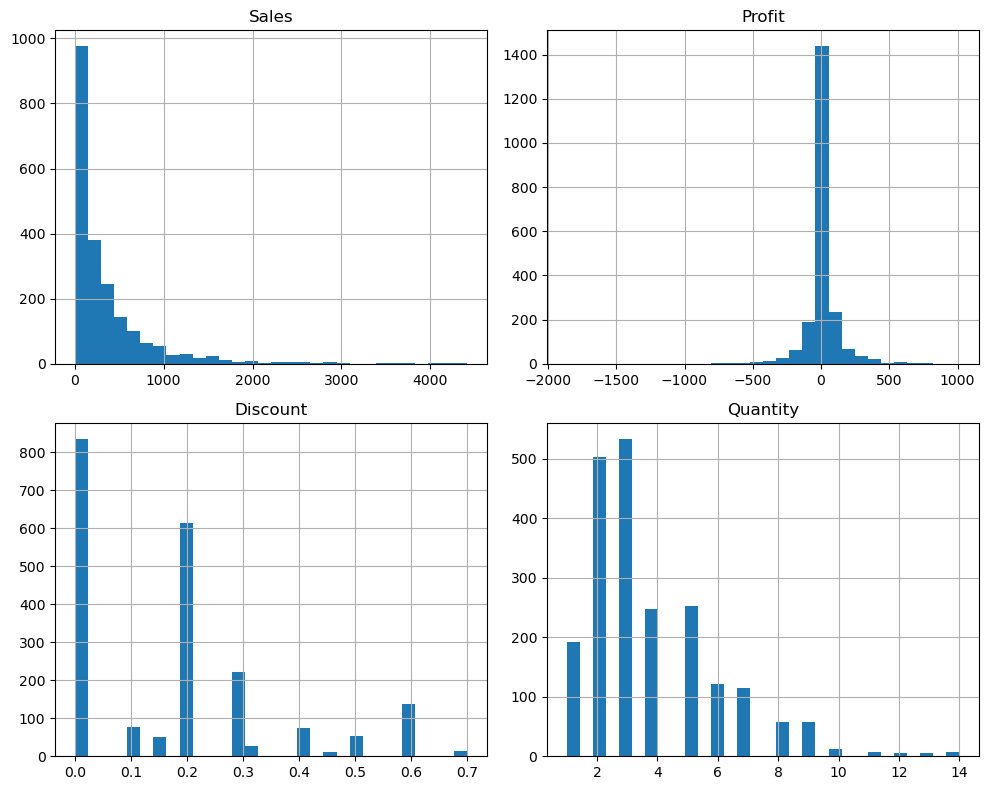

In [241]:
num_cols = ["Sales", "Profit", "Discount", "Quantity"]
df[num_cols].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

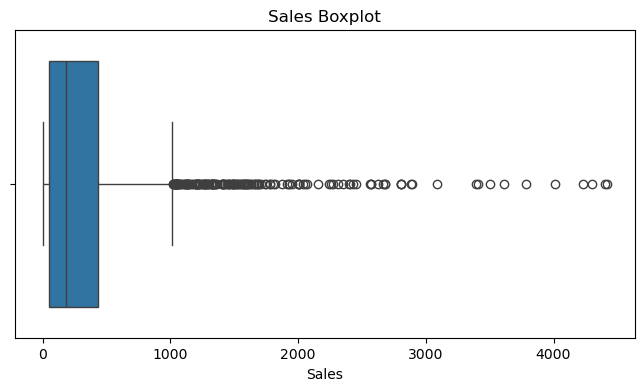

In [242]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Sales"])
plt.title("Sales Boxplot")
plt.show()

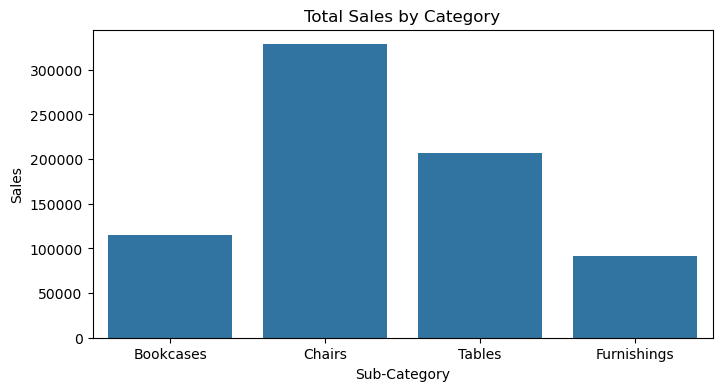

In [243]:
plt.figure(figsize=(8, 4))
sns.barplot(x="Sub-Category", y="Sales", data=df, estimator=sum, errorbar=None)
plt.title("Total Sales by Category")
plt.show()


In [244]:

Q1 = df_encoded["Sales"].quantile(0.25)
Q3 = df_encoded["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR   
upper = Q3 + 1.5 * IQR  

print(f"nomaral range: {lower:.2f} ~ {upper:.2f}")

outliers = df_encoded[(df_encoded["Sales"] < lower) | (df_encoded["Sales"] > upper)]
print("Sales Number of outliers:", len(outliers))

nomaral range: -535.15 ~ 1017.36
Sales Number of outliers: 164


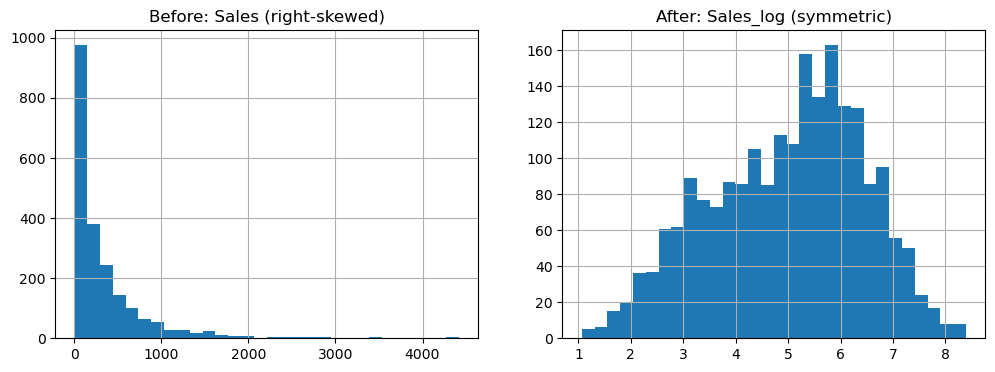

In [245]:


df_encoded["Sales_log"] = np.log1p(df_encoded["Sales"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_encoded["Sales"].hist(bins=30, ax=axes[0])
axes[0].set_title("Before: Sales (right-skewed)")
df_encoded["Sales_log"].hist(bins=30, ax=axes[1])
axes[1].set_title("After: Sales_log (symmetric)")
plt.show()


In [246]:
scale_cols = ["Quantity", "Discount", "Profit", "Sales_log"]
scaler = StandardScaler()
# copy and avoid desturct oprigin database
df_scaled = df_encoded.copy()

# standard
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

df_scaled[scale_cols].describe()


,Quantity,Discount,Profit,Sales_log
count,2.121000e+03,2.121000e+03,2.121000e+03,2.121000e+03
mean,-6.113817e-17,5.360058e-17,-1.926271e-17,2.479027e-16
std,1.000236e+00,1.000236e+00,1.000236e+00,1.000236e+00
min,-1.237182e+00,-9.582280e-01,-1.375570e+01,-2.685761e+00
25%,-7.929525e-01,-9.582280e-01,-1.584236e-01,-7.620225e-01
50%,-3.487232e-01,1.436732e-01,-6.797135e-03,1.543978e-01
75%,5.397355e-01,6.946237e-01,1.840008e-01,7.481645e-01
max,4.537800e+00,2.898426e+00,7.384565e+00,2.333132e+00


## 4. Identify correlated variables

In [247]:

df.groupby("Segment")[["Profit", "Quantity", "Sales"]].mean()

,Profit,Quantity,Sales
Segment,,,
Consumer,6.281293,3.743037,351.347091
Corporate,11.741201,3.862229,354.519792
Home Office,10.705465,3.776243,336.825131


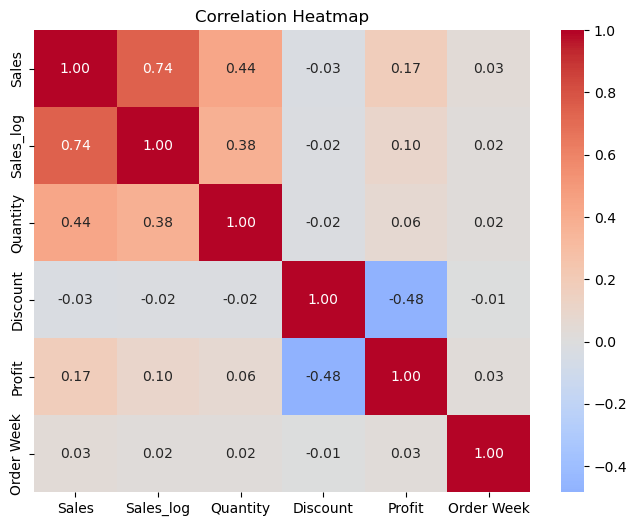

In [248]:
corr_cols = ["Sales", "Sales_log", "Quantity", "Discount", "Profit", "Order Week"]
corr = df_scaled[corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:

df.groupby("Order Month")[["Discount", "Quantity", "Sales"]].mean()

,Discount,Quantity,Sales
Order Month,,,
1,0.157037,4.259259,389.743723
2,0.178889,3.301587,250.252705
3,0.182143,3.764286,362.630541
4,0.163551,3.688406,294.917272
5,0.187267,3.920000,322.434205
6,0.191310,3.710345,365.513540
7,0.166463,3.768293,301.079341
8,0.183790,3.717742,361.968105
9,0.154468,3.542553,377.236137


In [250]:
df.groupby("Region")[["Sales", "Profit", "Discount"]].mean()

,Sales,Profit,Discount
Region,,,
Central,340.534644,-5.968918,0.297380
East,346.574383,5.068496,0.154077
South,353.309289,20.395199,0.121536
West,357.302325,16.272914,0.131400


## 5. Summary



1. **Loading & understanding the data.** Loaded the X-store `store_sales.csv`
   (2,121 rows × 21 columns) using `latin-1` encoding. Used `info()` and
   `describe()` to inspect data types and key statistics. The dataset contains
   **no missing values**, so no imputation was required.

2. **Type conversion.** Converted `Order Date` and `Ship Date` from text to
   `datetime`, then extracted numeric time features (`Order Year`, `Order Month`,
   `Order Week`, `Order Weekday`) so the model can learn seasonality and trends.

3. **Visualisation.** Plotted histograms, a boxplot and bar charts. `Sales` and
   `Profit` are strongly right-skewed with long tails; the boxplot confirmed many
   large-value outliers in `Sales`. A bar chart by `Sub-Category` showed Chairs
   sell the most and Furnishings the least.

4. **Cleaning & encoding.** Dropped non-predictive columns (IDs, customer/product
   names, and single-value columns `Category` (all "Furniture") and `Country`
   (all "United States")). One-Hot encoded the categorical columns `Ship Mode`,
   `Segment`, `Region` and `Sub-Category` into 0/1 features.

5. **Outlier handling.** `Sales` had ~164 outliers (7.7%) by the IQR rule. As
   these are genuine large orders rather than errors, I did **not** delete them;
   instead I applied a `log1p` transform, which turned the skewed distribution
   into a near-symmetric one while keeping all data.

6. **Standardisation.** Applied `StandardScaler` to the continuous features
   (`Quantity`, `Discount`, `Profit`, `Sales_log`) so they share a common scale
   (mean ≈ 0, std ≈ 1). One-Hot and date features were left unchanged.

7. **Correlation & feature selection.** Built a correlation heatmap and grouped
   summaries. Found `Order Month` and `Order Week` are 0.95 correlated
   (redundant), so I dropped `Order Month` to avoid multicollinearity, and
   exported the cleaned dataset for modelling in Part 2.

### Interesting findings

- **Discounts erode profit.** `Discount` and `Profit` are negatively correlated
  (-0.48). The regional breakdown confirmed this: the **Central** region gives the
  highest average discount (0.30) and is the **only region with negative average
  profit** (-5.97), while **South** discounts least (0.12) and is most profitable
  (20.4).
- **Customer type matters for profit, not sales.** All three segments have similar
  average sales (~340-355), but **Corporate** customers are nearly twice as
  profitable (11.7) as **Consumer** (6.3).
- **Seasonality exists.** Average sales peak in January (390) and dip in February
  (250), confirming that time features are valuable for forecasting.